1D CNN Autoencoder architecture trained using k-Fold validation method for avoiding overfitting

In [205]:
'''
X_hip = scaler.fit_transform(X_hip)
y_hip = scaler.fit_transform(y_hip)
X_knee = scaler.fit_transform(X_knee)
y_knee = scaler.fit_transform(y_knee)
#nan value in X_knee and y_knee

X_knee = np.nan_to_num(X_knee, nan=0.0, posinf=0.0, neginf=0.0)
y_knee = np.nan_to_num(y_knee, nan=0.0, posinf=0.0, neginf=0.0)
#Reshape data for model input
X_hip = X_hip[...,np.newaxis]
y_hip = y_hip[...,np.newaxis]
X_knee = X_knee[...,np.newaxis]
y_knee = y_knee[...,np.newaxis] #adds a new dimension (samples, timesteps, features)'''

'\nX_hip = scaler.fit_transform(X_hip)\ny_hip = scaler.fit_transform(y_hip)\nX_knee = scaler.fit_transform(X_knee)\ny_knee = scaler.fit_transform(y_knee)\n#nan value in X_knee and y_knee\n\nX_knee = np.nan_to_num(X_knee, nan=0.0, posinf=0.0, neginf=0.0)\ny_knee = np.nan_to_num(y_knee, nan=0.0, posinf=0.0, neginf=0.0)\n#Reshape data for model input\nX_hip = X_hip[...,np.newaxis]\ny_hip = y_hip[...,np.newaxis]\nX_knee = X_knee[...,np.newaxis]\ny_knee = y_knee[...,np.newaxis] #adds a new dimension (samples, timesteps, features)'

In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, UpSampling1D, MaxPooling1D, Dense, Flatten, Reshape
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

dataset = pd.read_csv(r"C:\Users\Admin\Desktop\CP\Data\processed\final_processed\GAIT_analysis_dataset.csv")

hip_cols = [col for col in dataset.columns if "aSagH_" in col] 
knee_cols = [col for col in dataset.columns if "aSagK_" in col]

hip_data = dataset[hip_cols].to_numpy()
knee_data = dataset[knee_cols].to_numpy()

print("hip_data shape:",hip_data.shape)
print("knee_data shape:",knee_data.shape)


hip_data shape: (551, 51)
knee_data shape: (551, 51)


In [207]:
# Get the patient IDs from the dataset
patient_ids = dataset["Patient ID"].unique()

# Shuffle the patient IDs to randomize selection
np.random.seed(42)  # For reproducibility
np.random.shuffle(patient_ids)

# Split into 450 training and 101 test patients
train_patient_ids = patient_ids[:450]
test_patient_ids = patient_ids[450:551]  # 450 to 550 (101 patients)

# Create boolean masks for selection
train_mask = dataset["Patient ID"].isin(train_patient_ids)
test_mask = dataset["Patient ID"].isin(test_patient_ids)

# Split hip and knee data
hip_train = dataset.loc[train_mask, hip_cols].to_numpy()
hip_test = dataset.loc[test_mask, hip_cols].to_numpy()

knee_train = dataset.loc[train_mask, knee_cols].to_numpy()
knee_test = dataset.loc[test_mask, knee_cols].to_numpy()

In [208]:
print(knee_train.shape)
print(hip_train.shape)
print(knee_test.shape)
print(hip_test.shape)

(450, 51)
(450, 51)
(101, 51)
(101, 51)


In [209]:
def create_sliding_window_dataset(data, window_size, step=1):
    X, y = [], []
    for seq in data:
        for i in range(0, len(seq) - 2 * window_size + 1, step):
            X.append(seq[i:i + window_size])
            y.append(seq[i + window_size:i + 2 * window_size])
    return np.array(X), np.array(y)

In [210]:
X_train_hip, y_train_hip = create_sliding_window_dataset(hip_train,window_size=17,step=5) #for window size = 15 step = 5 : shape (2755, 15). for window size = 19 step = 5 : shape (1653,19)
X_train_knee, y_train_knee = create_sliding_window_dataset(knee_train,window_size=17,step=5)#for window size = 15 step = 5 : shape (2755, 15). for window size = 19 step = 5 : shape (1653,19)
X_test_hip, y_test_hip = create_sliding_window_dataset(hip_test,window_size=17,step=5) #for window size = 15 step = 5 : shape (2755, 15). for window size = 19 step = 5 : shape (1653,19)
X_test_knee, y_test_knee = create_sliding_window_dataset(knee_test,window_size=17,step=5)#for window size = 15 step = 5 : shape (2755, 15). for window size = 19 step = 5 : shape (1653,19)

In [211]:
X_train_knee = np.nan_to_num(X_train_knee, nan=0.0, posinf=0.0, neginf=0.0)#knee had Nan value
y_train_knee = np.nan_to_num(y_train_knee, nan=0.0, posinf=0.0, neginf=0.0)
X_test_knee = np.nan_to_num(X_test_knee, nan=0.0, posinf=0.0, neginf=0.0)
y_test_knee = np.nan_to_num(y_test_knee, nan=0.0, posinf=0.0, neginf=0.0)

In [212]:
def normalize_sequences(X):
    scaler = MinMaxScaler()
    # Normalize each sample (sequence) independently, assuming X shape = (samples, timesteps)
    X_norm = np.array([scaler.fit_transform(seq.reshape(-1, 1)).flatten() for seq in X])
    return X_norm

# Apply it on your data, then add back the feature dimension
X_train_hip = normalize_sequences(X_train_hip.squeeze())[..., np.newaxis]
y_train_hip = normalize_sequences(y_train_hip.squeeze())[..., np.newaxis]
X_train_knee = normalize_sequences(X_train_knee.squeeze())[..., np.newaxis]
y_train_knee = normalize_sequences(y_train_knee.squeeze())[..., np.newaxis]
X_test_hip = normalize_sequences(X_test_hip.squeeze())[..., np.newaxis]
y_test_hip = normalize_sequences(y_test_hip.squeeze())[..., np.newaxis]
X_test_knee = normalize_sequences(X_test_knee.squeeze())[..., np.newaxis]
y_test_knee = normalize_sequences(y_test_knee.squeeze())[..., np.newaxis]

In [213]:
def get_window_patient_ids(patient_ids_seq, full_sequence_length, window_size, step=1):
    window_patient_ids = []
    for pid in patient_ids_seq:
        num_windows = (full_sequence_length - 2 * window_size) // step + 1
        window_patient_ids.extend([pid] * num_windows)
    return np.array(window_patient_ids)


In [214]:
window_size = 17
step = 5 # length of each full sequence in timesteps, e.g., 60

In [215]:
# Get the corresponding patient ID sequences
patient_ids_train_seq = dataset.loc[train_mask, 'Patient ID'].to_numpy()
patient_ids_test_seq = dataset.loc[test_mask, 'Patient ID'].to_numpy()

# Apply windowing to the patient ID sequences
window_patient_ids_train = get_window_patient_ids(
    patient_ids_seq=patient_ids_train_seq,
    full_sequence_length=hip_train.shape[1],
    window_size=window_size,
    step=step
)

window_patient_ids_test = get_window_patient_ids(
    patient_ids_seq=patient_ids_test_seq,
    full_sequence_length=hip_test.shape[1],
    window_size=window_size,
    step=step
)


In [216]:
#model building
import tensorflow as tf

class CNN_Autoencoder(tf.keras.Model):
    def __init__(self, 
                 latent_dim=64, 
                 conv_filters=[64, 128, 256], 
                 kernel_size=3, 
                 strides=2, 
                 activation='relu',
                 dropout_rate=0.25,
                 l2_lambda=1e-4,**kwargs):
        super(CNN_Autoencoder, self).__init__(**kwargs)

        self.latent_dim = latent_dim
        self.activation = activation
        self.conv_filters = conv_filters
        self.kernel_size = kernel_size
        self.strides = strides
        self.dropout_rate = dropout_rate
        self.l2 = regularizers.l2(l2_lambda)

        # Encoder layers with regularization and dropout
        self.encoder_layers = []
        for f in conv_filters:
            self.encoder_layers.append(
                layers.Conv1D(f, kernel_size, strides=strides, padding='same',
                              activation=activation, kernel_regularizer=self.l2)
            )
            self.encoder_layers.append(layers.BatchNormalization())
            self.encoder_layers.append(layers.Activation(activation))
            self.encoder_layers.append(layers.Dropout(dropout_rate))


        self.flatten = layers.Flatten()
        self.bottleneck = layers.Dense(latent_dim, activation=activation, kernel_regularizer=self.l2)

        # Decoder layers (created later in build())
        self.decoder_layers = []
        self.dense = None
        self.reshape_layer = None
        self.output_layer = None

    def build(self, input_shape):
        # Apply encoder to dummy input to get output shape
        x = layers.Input(shape=input_shape[1:])
        z = x
        for layer in self.encoder_layers:
            z = layer(z)

        encoded_shape = z.shape  # [None, reduced_timesteps, channels]
        self.encoded_timesteps = encoded_shape[1]
        self.encoded_channels = encoded_shape[2]

        # Decoder layers now that we know the shape
        self.dense = layers.Dense(self.encoded_timesteps * self.encoded_channels, activation=self.activation)
        self.reshape_layer = layers.Reshape((self.encoded_timesteps, self.encoded_channels))

        # Mirror the conv filters for decoder
        for f in reversed(self.conv_filters):
            self.decoder_layers.append(
                layers.Conv1DTranspose(f, self.kernel_size, strides=self.strides, padding='same', activation=self.activation)
            )

        self.output_layer = layers.Conv1D(1, self.kernel_size, padding='same', activation='linear')
        
        super().build(input_shape)  # Let Keras know the model is built

    def encode(self, inputs):
        x = inputs
        for layer in self.encoder_layers:
            x = layer(x)
        x = self.flatten(x)
        x = self.bottleneck(x)
        return x


    def call(self, inputs):
        x = inputs
        for layer in self.encoder_layers:
            x = layer(x)
        x = self.flatten(x)
        x = self.bottleneck(x)
        x = self.dense(x)
        x = self.reshape_layer(x)
        for layer in self.decoder_layers:
            x = layer(x)
        x = self.output_layer(x)

        # Crop or slice to match input timesteps
        x = x[:, :inputs.shape[1], :]  # Ensure final output is same length as input
        return x

In [217]:
def get_conv_filters(filter_option):
    # Map options to actual filter configs
    if filter_option == 'option1':
        return [32, 64]
    elif filter_option == 'option2':
        return [64, 128]
    elif filter_option == 'option3':
        return [32,64,128]
    else:
        return [64, 128, 256]

In [218]:
#hyperparameter tuning
from keras_tuner import HyperParameters
from keras_tuner.tuners import RandomSearch

def build_model(hp):
    filter_option = hp.Choice('conv_filter_option', values=['option1', 'option2', 'option3', 'option4'])

    conv_filters = get_conv_filters(filter_option)
    latent_dim = 80
    kernel_size = hp.Choice('kernel_size', values=[3, 5])
    strides = hp.Choice('strides', values=[1, 2])
    activation = hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    l2_lambda = hp.Float('l2_lambda', 1e-5, 1e-3, sampling='log')

    def reconstruction_accuracy(y_true, y_pred):
        return tf.reduce_mean(tf.cast(tf.less_equal(tf.abs(y_true - y_pred), 0.1), tf.float32))

    model = CNN_Autoencoder(latent_dim, conv_filters, kernel_size, strides, activation, dropout_rate, l2_lambda)
    model.compile(optimizer='adam', loss='mse', metrics=[reconstruction_accuracy])
    return model

In [219]:
# Tuner for HIP
tuner_hip = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='autoencoder_tuning',
    project_name='cnn_autoencoder_hip'
)

# Tuner for KNEE
tuner_knee = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='autoencoder_tuning',
    project_name='cnn_autoencoder_knee'
)

# Perform hyperparameter search
tuner_hip.search(X_train_hip, y_train_hip, epochs=20, validation_split=0.2, batch_size=32,
                 callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)])

tuner_knee.search(X_train_knee, y_train_knee, epochs=20, validation_split=0.2, batch_size=32,
                  callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)])


Reloading Tuner from autoencoder_tuning\cnn_autoencoder_hip\tuner0.json
Reloading Tuner from autoencoder_tuning\cnn_autoencoder_knee\tuner0.json


In [220]:
#saving hp tuned parameters

# Save best HIP model
best_hip = tuner_hip.get_best_models(num_models=1)[0]
best_hip.save(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\hip\best_cnn_autoencoder_hip.h5')

# Save best KNEE model
best_knee = tuner_knee.get_best_models(num_models=1)[0]
best_knee.save(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\knee\best_cnn_autoencoder_knee.h5')


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [221]:
best_hip.save(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\hip\model_hip.keras')  # or without extension for SavedModel
best_knee.save(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\knee\model_knee.keras')  # or without extension for SavedModel

In [222]:
# Evaluate and save metrics
from sklearn.model_selection import train_test_split

#for hip

X_train, X_val_hip = train_test_split(X_train_hip, test_size=0.25, random_state=42)
val_loss, val_accuracy = best_hip.evaluate(X_val_hip, X_val_hip)  # autoencoder: input = target
best_hip_hp = tuner_hip.get_best_hyperparameters(num_trials=1)[0]
with open(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\hip\metrics.txt', 'w') as f:
    for param, value in best_hip_hp.values.items():
        f.write(f"{param}: {value}\n")
    f.write(f"Validation Loss: {val_loss}\n")
    f.write(f"Reconstruction Accuracy: {val_accuracy}\n")
    
#for knee

X_train, X_val_knee = train_test_split(X_train_knee, test_size=0.25, random_state=42)
val_loss, val_accuracy = best_hip.evaluate(X_val_knee, X_val_knee)  # autoencoder: input = target
best_knee_hp = tuner_knee.get_best_hyperparameters(num_trials=1)[0]
with open(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\knee\metrics.txt', 'w') as f:
    for param, value in best_knee_hp.values.items():
        f.write(f"{param}: {value}\n")
    f.write(f"Validation Loss: {val_loss}\n")
    f.write(f"Reconstruction Accuracy: {val_accuracy}\n")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3134 - reconstruction_accuracy: 0.2038
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2599 - reconstruction_accuracy: 0.3285


In [223]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42) #kfolds 


Fold 1
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1724 - reconstruction_accuracy: 0.2546 - val_loss: 0.0370 - val_reconstruction_accuracy: 0.4272
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0344 - reconstruction_accuracy: 0.4759 - val_loss: 0.0303 - val_reconstruction_accuracy: 0.5687
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0292 - reconstruction_accuracy: 0.5521 - val_loss: 0.0316 - val_reconstruction_accuracy: 0.5719
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0301 - reconstruction_accuracy: 0.5454 - val_loss: 0.0283 - val_reconstruction_accuracy: 0.5960
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0264 - reconstruction_accuracy: 0.5981 - val_loss: 0.0256 - val_reconstruction_accuracy: 0.6277
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0263 - reconstruction_accuracy: 0.5905 - val_loss: 0.0312 - val_reconstruction_accuracy: 0.4632
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

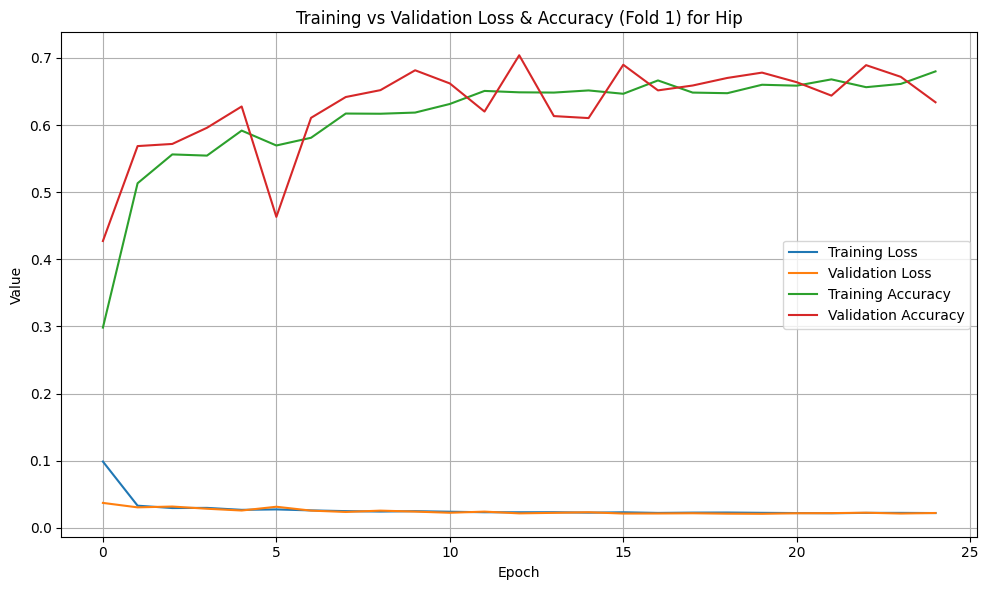


Fold 2
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.1472 - reconstruction_accuracy: 0.2685 - val_loss: 0.0352 - val_reconstruction_accuracy: 0.5136
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0330 - reconstruction_accuracy: 0.5103 - val_loss: 0.0291 - val_reconstruction_accuracy: 0.5622
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0281 - reconstruction_accuracy: 0.5809 - val_loss: 0.0292 - val_reconstruction_accuracy: 0.5798
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0309 - reconstruction_accuracy: 0.5415 - val_loss: 0.0275 - val_reconstruction_accuracy: 0.5837
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0267 - reconstruction_accuracy: 0.5841 - val_loss: 0.0254 - val_reconstruction_accuracy: 0.6091
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0265 - reconstruction_accuracy: 0.5932 - val_loss: 0.0252 - val_reconstruction_accuracy: 0.5893
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

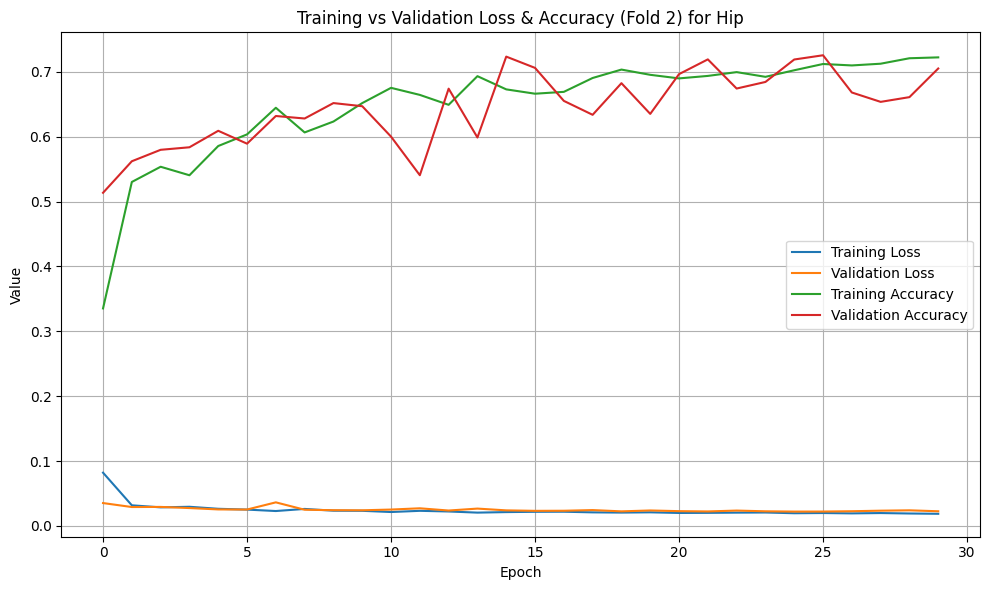


Fold 3
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1607 - reconstruction_accuracy: 0.2708 - val_loss: 0.0360 - val_reconstruction_accuracy: 0.4609
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0336 - reconstruction_accuracy: 0.4977 - val_loss: 0.0314 - val_reconstruction_accuracy: 0.5686
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0310 - reconstruction_accuracy: 0.5419 - val_loss: 0.0292 - val_reconstruction_accuracy: 0.5996
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0281 - reconstruction_accuracy: 0.5714 - val_loss: 0.0255 - val_reconstruction_accuracy: 0.6079
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0284 - reconstruction_accuracy: 0.5806 - val_loss: 0.0244 - val_reconstruction_accuracy: 0.6079
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0255 - reconstruction_accuracy: 0.6011 - val_loss: 0.0266 - val_reconstruction_accuracy: 0.6233
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

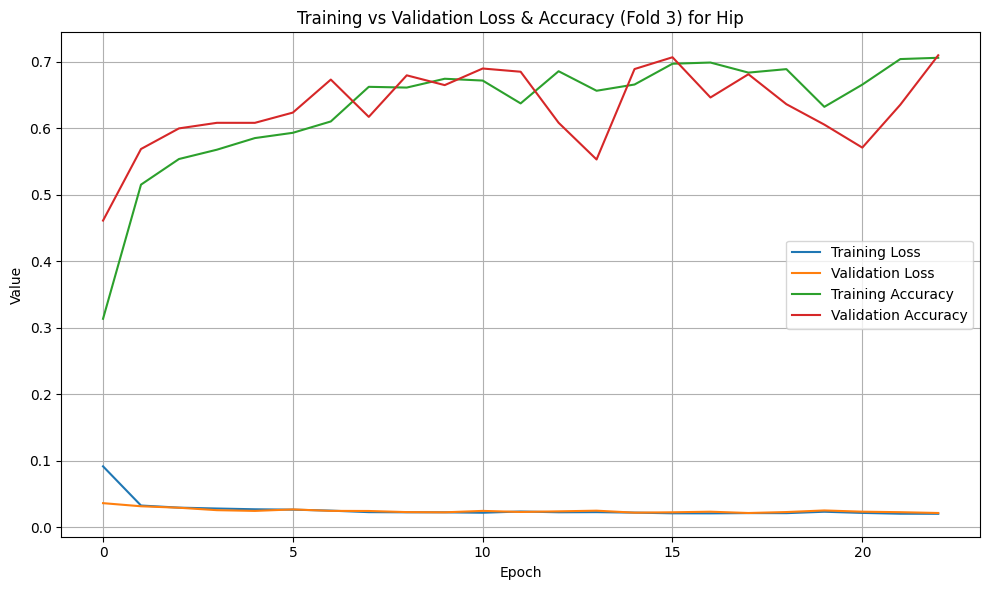


Fold 1
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.2447 - reconstruction_accuracy: 0.2278 - val_loss: 0.0593 - val_reconstruction_accuracy: 0.4575
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0555 - reconstruction_accuracy: 0.4863 - val_loss: 0.0444 - val_reconstruction_accuracy: 0.5248
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0442 - reconstruction_accuracy: 0.5530 - val_loss: 0.0391 - val_reconstruction_accuracy: 0.5631
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0391 - reconstruction_accuracy: 0.5729 - val_loss: 0.0353 - val_reconstruction_accuracy: 0.6427
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0365 - reconstruction_accuracy: 0.6063 - val_loss: 0.0332 - val_reconstruction_accuracy: 0.6464
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0343 - reconstruction_accuracy: 0.6286 - val_loss: 0.0312 - val_reconstruction_accuracy: 0.6422
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

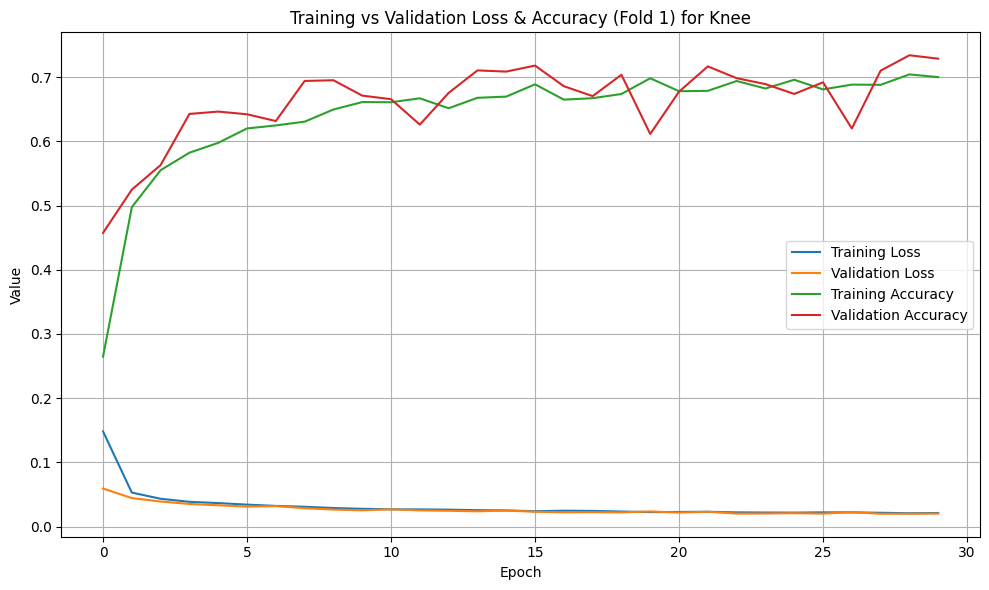


Fold 2
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.2842 - reconstruction_accuracy: 0.2212 - val_loss: 0.0625 - val_reconstruction_accuracy: 0.3973
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0568 - reconstruction_accuracy: 0.4375 - val_loss: 0.0463 - val_reconstruction_accuracy: 0.5368
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0443 - reconstruction_accuracy: 0.5397 - val_loss: 0.0417 - val_reconstruction_accuracy: 0.5364
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0399 - reconstruction_accuracy: 0.5524 - val_loss: 0.0372 - val_reconstruction_accuracy: 0.5694
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0390 - reconstruction_accuracy: 0.5753 - val_loss: 0.0369 - val_reconstruction_accuracy: 0.6194
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0361 - reconstruction_accuracy: 0.5922 - val_loss: 0.0338 - val_reconstruction_accuracy: 0.6308
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

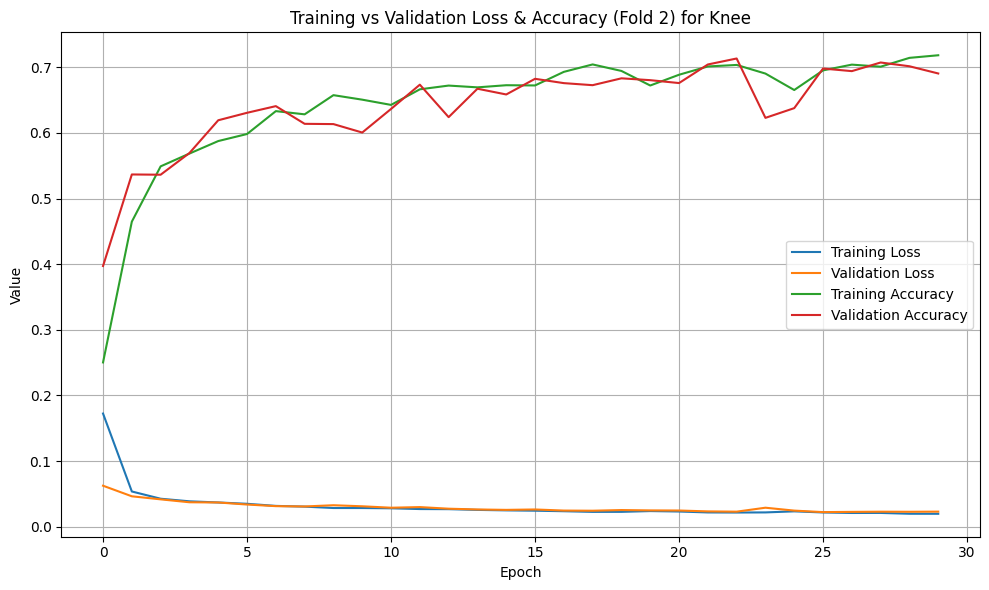


Fold 3
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.2810 - reconstruction_accuracy: 0.2348 - val_loss: 0.0684 - val_reconstruction_accuracy: 0.2894
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0588 - reconstruction_accuracy: 0.4138 - val_loss: 0.0489 - val_reconstruction_accuracy: 0.4870
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0458 - reconstruction_accuracy: 0.5368 - val_loss: 0.0411 - val_reconstruction_accuracy: 0.5477
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0398 - reconstruction_accuracy: 0.5655 - val_loss: 0.0400 - val_reconstruction_accuracy: 0.5528
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0379 - reconstruction_accuracy: 0.5937 - val_loss: 0.0369 - val_reconstruction_accuracy: 0.5450
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0320 - reconstruction_accuracy: 0.6186 - val_loss: 0.0348 - val_reconstruction_accuracy: 0.6265
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

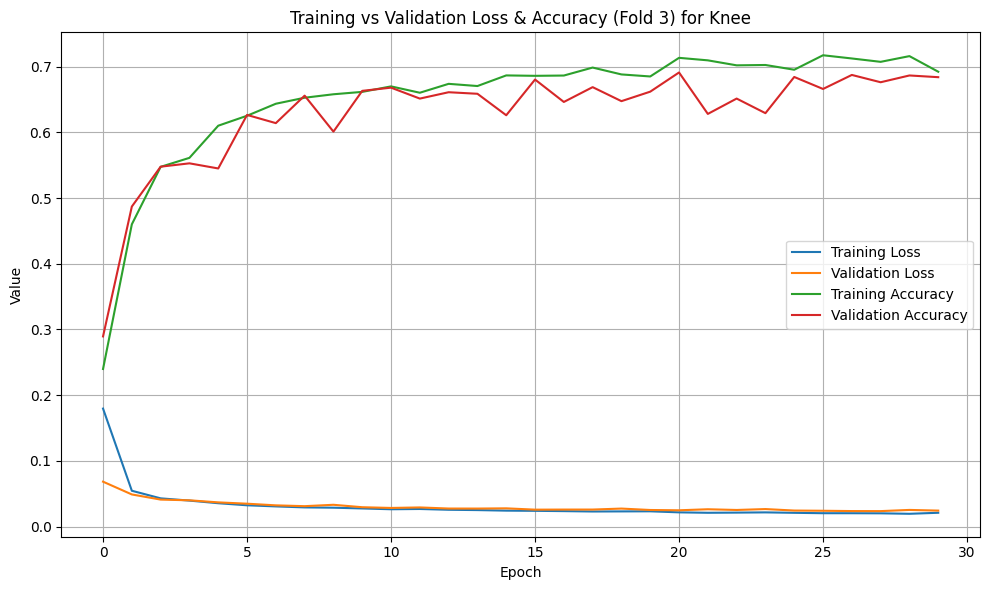

In [224]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Custom accuracy-like metric for autoencoder
def reconstruction_accuracy(y_true, y_pred):
    return tf.reduce_mean(tf.cast(tf.less_equal(tf.abs(y_true - y_pred), 0.1), tf.float32))

# Training for hip
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_hip)):
    print(f"\nFold {fold+1}")
    #model_hip = CNN_Autoencoder(latent_dim=32,conv_filters=[32,64,128])
    best_hp = tuner_hip.get_best_hyperparameters(1)[0]
    filter_option = best_hp['conv_filter_option']
    if filter_option == 'option1':
        conv_filters = [32, 64]
    elif filter_option == 'option2':
        conv_filters = [64, 128]
    elif filter_option == 'option3':
        conv_filters = [32, 64, 128]
    else:
        conv_filters = [64, 128, 256]

    model_hip = CNN_Autoencoder(
    latent_dim=best_hp['latent_dim'],
    conv_filters=conv_filters,  # set according to best_hp
    kernel_size=best_hp['kernel_size'],
    strides=best_hp['strides'],
    activation=best_hp['activation'],
    dropout_rate=best_hp['dropout_rate'],
    l2_lambda=best_hp['l2_lambda']
    )
    model_hip.build(input_shape=(None, X_train_hip.shape[1], X_train_hip.shape[2]))
    model_hip.load_weights(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\hip\model_hip.keras')
    
    model_hip.compile(optimizer='adam', loss='mse', metrics=[reconstruction_accuracy])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history_hip = model_hip.fit(X_train_hip[train_idx], y_train_hip[train_idx],
                                validation_data=(X_train_hip[val_idx], y_train_hip[val_idx]),
                                epochs=30, batch_size=32, verbose=1,
                                callbacks=[early_stop])

    # Plotting loss and accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(history_hip.history['loss'], label='Training Loss')
    plt.plot(history_hip.history['val_loss'], label='Validation Loss')
    plt.plot(history_hip.history['reconstruction_accuracy'], label='Training Accuracy')
    plt.plot(history_hip.history['val_reconstruction_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title(f'Training vs Validation Loss & Accuracy (Fold {fold+1}) for Hip')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(rf'C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\K-folds\hip\hip_loss_plot_Fold_{fold+1}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Training for knee
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_knee)):
    print(f"\nFold {fold+1}")
    #model_knee = CNN_Autoencoder(latent_dim=32,conv_filters=[32,64,128])
    #model_hip = CNN_Autoencoder(latent_dim=32,conv_filters=[32,64,128])
    best_hp = tuner_knee.get_best_hyperparameters(1)[0]
    filter_option = best_hp['conv_filter_option']
    if filter_option == 'option1':
        conv_filters = [32, 64]
    elif filter_option == 'option2':
        conv_filters = [64, 128]
    elif filter_option == 'option3':
        conv_filters = [32, 64, 128]
    else:
        conv_filters = [64, 128, 256]
    model_knee = CNN_Autoencoder(
    latent_dim=best_hp['latent_dim'],
    conv_filters=conv_filters,  # set according to best_hp
    kernel_size=best_hp['kernel_size'],
    strides=best_hp['strides'],
    activation=best_hp['activation'],
    dropout_rate=best_hp['dropout_rate'],
    l2_lambda=best_hp['l2_lambda']
    )
    model_knee.build(input_shape=(None, X_train_hip.shape[1], X_train_hip.shape[2]))
    model_knee.load_weights(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\knee\model_knee.keras')

    model_knee.compile(optimizer='adam', loss='mse', metrics=[reconstruction_accuracy])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history_knee = model_knee.fit(X_train_knee[train_idx], y_train_knee[train_idx],
                                  validation_data=(X_train_knee
                                  
                                  [val_idx], y_train_knee[val_idx]),
                                  epochs=30, batch_size=32, verbose=1,
                                  callbacks=[early_stop])

    # Plotting loss and accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(history_knee.history['loss'], label='Training Loss')
    plt.plot(history_knee.history['val_loss'], label='Validation Loss')
    plt.plot(history_knee.history['reconstruction_accuracy'], label='Training Accuracy')
    plt.plot(history_knee.history['val_reconstruction_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title(f'Training vs Validation Loss & Accuracy (Fold {fold+1}) for Knee')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(rf'C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\K-folds\knee\knee_loss_plot_Fold_{fold+1}.png', dpi=300, bbox_inches='tight')
    plt.show()

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1309 - reconstruction_accuracy: 0.3003
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0303 - reconstruction_accuracy: 0.5483
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0287 - reconstruction_accuracy: 0.5788
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0259 - reconstruction_accuracy: 0.5668
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0260 - reconstruction_accuracy: 0.5803
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0244 - reconstruction_accuracy: 0.6073
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0229 - reconstruction_accuracy: 0.6617
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0234 - reconstruction_accuracy: 0.6373
Epoch 9/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0217 - reconstruction_accuracy: 0.6625
Epoch 10/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0222 - reconstruction_accuracy: 0.6522

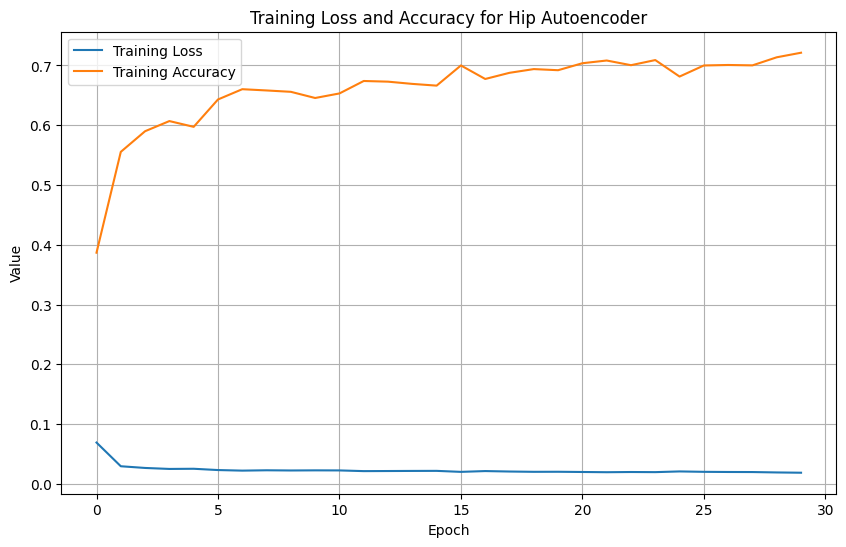

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2233 - reconstruction_accuracy: 0.2486
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0469 - reconstruction_accuracy: 0.5096
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0376 - reconstruction_accuracy: 0.5728
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0361 - reconstruction_accuracy: 0.6006
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0301 - reconstruction_accuracy: 0.6423
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0293 - reconstruction_accuracy: 0.6512
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0287 - reconstruction_accuracy: 0.6399
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0265 - reconstruction_accuracy: 0.6555
Epoch 9/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0275 - reconstruction_accuracy: 0.6488
Epoch 10/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0265 - reconstruction_accuracy: 0.6722

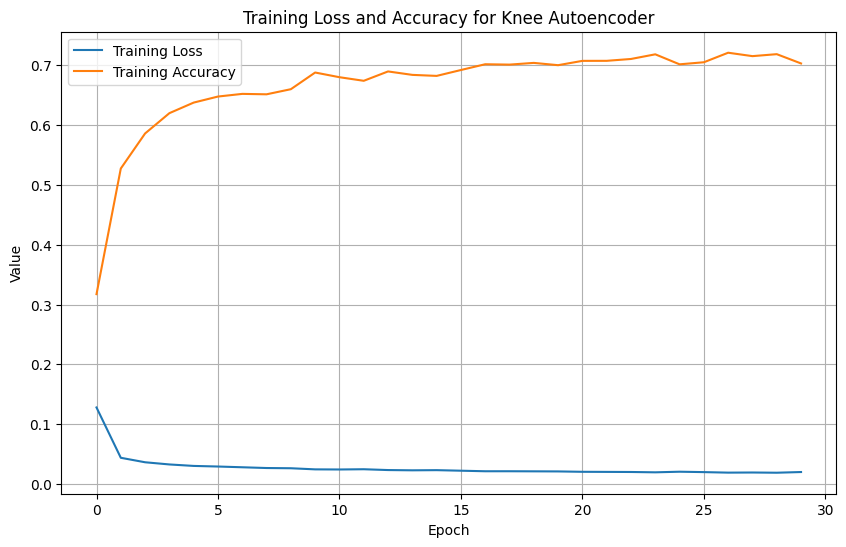

In [225]:
#Define and compile final model for hip
from tensorflow.keras.models import load_model

best_hp = tuner_hip.get_best_hyperparameters(1)[0]
filter_option = best_hp['conv_filter_option']
if filter_option == 'option1':
    conv_filters = [32, 64]
elif filter_option == 'option2':
    conv_filters = [64, 128]
elif filter_option == 'option3':
    conv_filters = [32, 64, 128]
else:
    conv_filters = [64, 128, 256]

final_model_hip = CNN_Autoencoder(
latent_dim=80,
conv_filters=conv_filters,  # set according to best_hp
kernel_size=best_hp['kernel_size'],
strides=best_hp['strides'],
activation=best_hp['activation'],
dropout_rate=best_hp['dropout_rate'],
l2_lambda=best_hp['l2_lambda']
)
final_model_hip.build(input_shape=(None, X_train_hip.shape[1], X_train_hip.shape[2]))
final_model_hip.load_weights(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\hip\model_hip.keras')
# Optionally fine-tune on full training data
final_model_hip.compile(optimizer='adam', loss='mse', metrics=[reconstruction_accuracy])

# Train on full hip training data
history_hip = final_model_hip.fit(X_train_hip, y_train_hip,
                                 epochs=30, batch_size=32, verbose=1)

# Plot loss and accuracy for hip
plt.figure(figsize=(10,6))
plt.plot(history_hip.history['loss'], label='Training Loss')
plt.plot(history_hip.history['reconstruction_accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Accuracy for Hip Autoencoder')
plt.legend()
plt.grid(True)
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\training\training_loss_plot_hip.png',dpi=300, bbox_inches='tight')
plt.show()

# Get latent vectors for hip training set
latent_vectors_hip = final_model_hip.encode(X_train_hip).numpy()


# Define and compile final model for knee
best_hp = tuner_knee.get_best_hyperparameters(1)[0]
filter_option = best_hp['conv_filter_option']
if filter_option == 'option1':
    conv_filters = [32, 64]
elif filter_option == 'option2':
    conv_filters = [64, 128]
elif filter_option == 'option3':
    conv_filters = [32, 64, 128]
else:
    conv_filters = [64, 128, 256]

final_model_knee = CNN_Autoencoder(
latent_dim=80,
conv_filters=conv_filters,  # set according to best_hp
kernel_size=best_hp['kernel_size'],
strides=best_hp['strides'],
activation=best_hp['activation'],
dropout_rate=best_hp['dropout_rate'],
l2_lambda=best_hp['l2_lambda']
)
final_model_knee.build(input_shape=(None, X_train_hip.shape[1], X_train_hip.shape[2]))
final_model_knee.load_weights(r'C:\Users\Admin\Desktop\CP\Outputs\HP\Version 1\knee\model_knee.keras')

final_model_knee.compile(optimizer='adam', loss='mse', metrics=[reconstruction_accuracy])

# Train on full knee training data
history_knee = final_model_knee.fit(X_train_knee, y_train_knee,
                                   epochs=30, batch_size=32, verbose=1)

# Plot loss and accuracy for knee
plt.figure(figsize=(10,6))
plt.plot(history_knee.history['loss'], label='Training Loss')
plt.plot(history_knee.history['reconstruction_accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Accuracy for Knee Autoencoder')
plt.legend()
plt.grid(True)
plt.savefig(r'C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\training\training_loss_plot_knee.png',dpi=300, bbox_inches='tight')
plt.show()

# Get latent vectors for knee training set
latent_vectors_knee = final_model_knee.encode(X_train_knee).numpy()


# Save latent vectors for clustering or further analysis
np.save(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\latent_vectors_hip.npy', latent_vectors_hip)
np.save(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\latent_vectors_knee.npy', latent_vectors_knee)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0209 - reconstruction_accuracy: 0.6981 
Test Loss: 0.0204
Test Reconstruction Accuracy: 0.7048
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


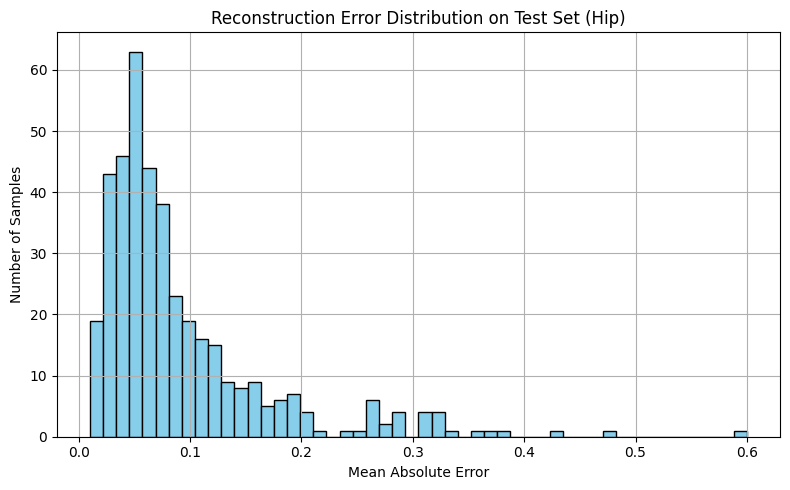

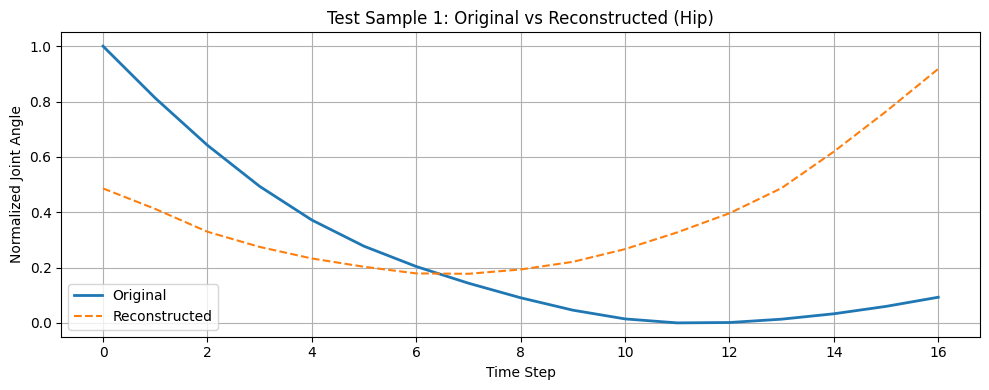

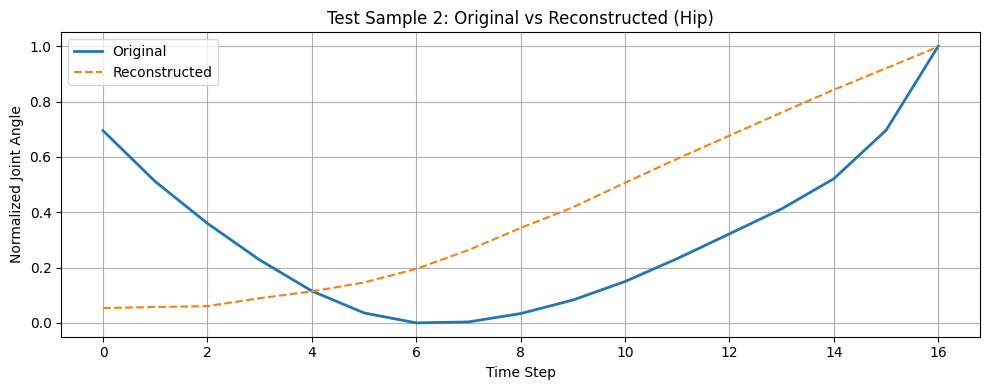

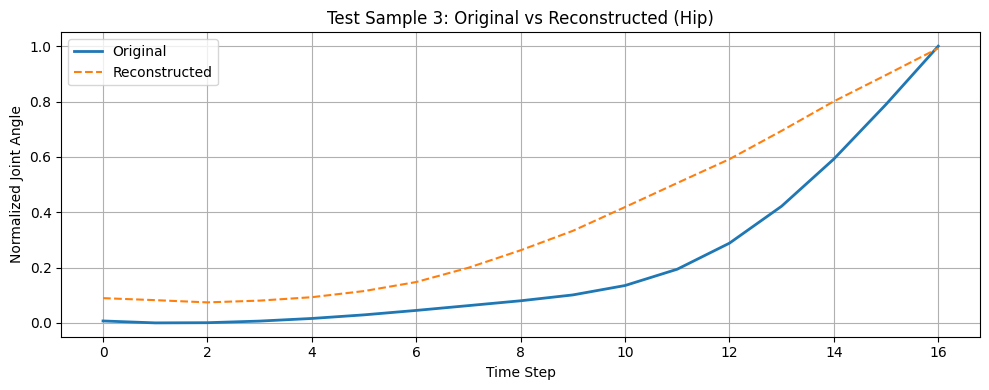

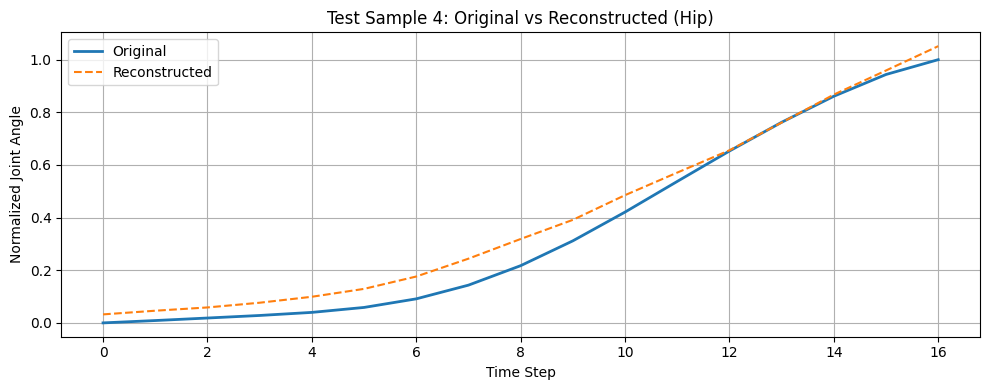

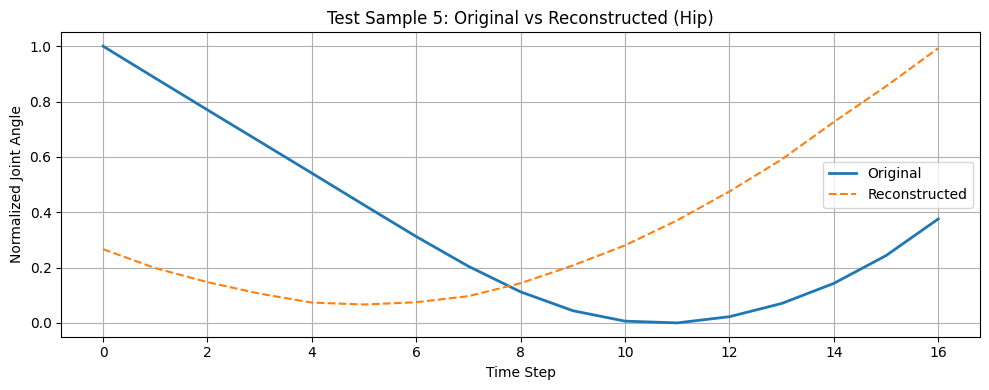

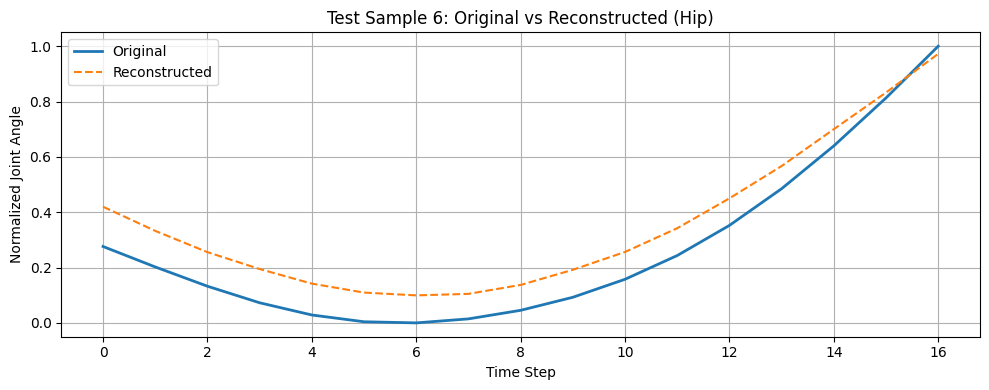

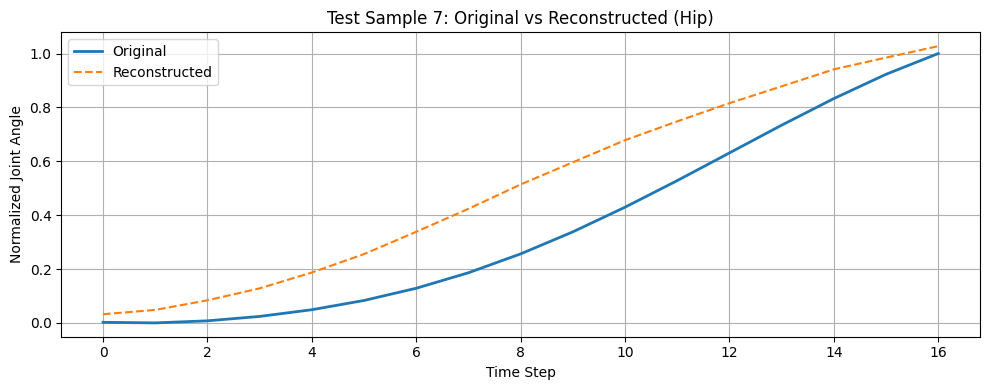

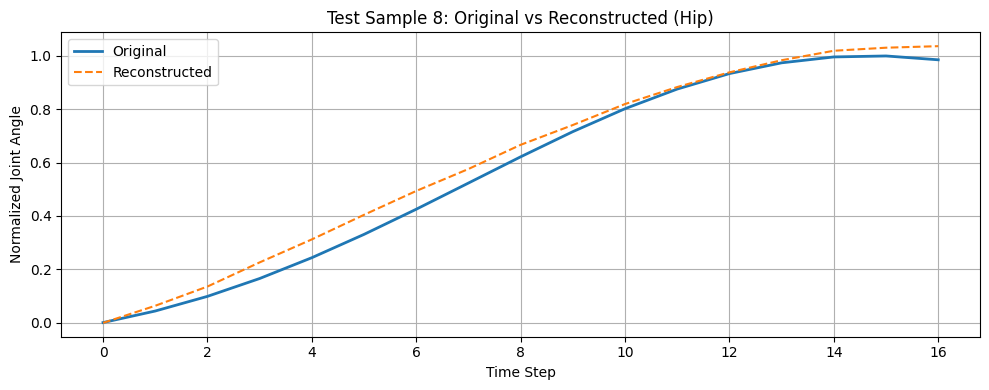

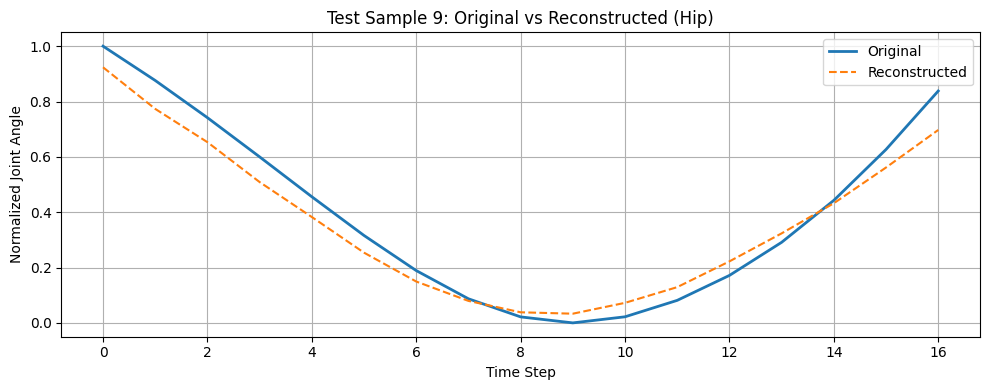

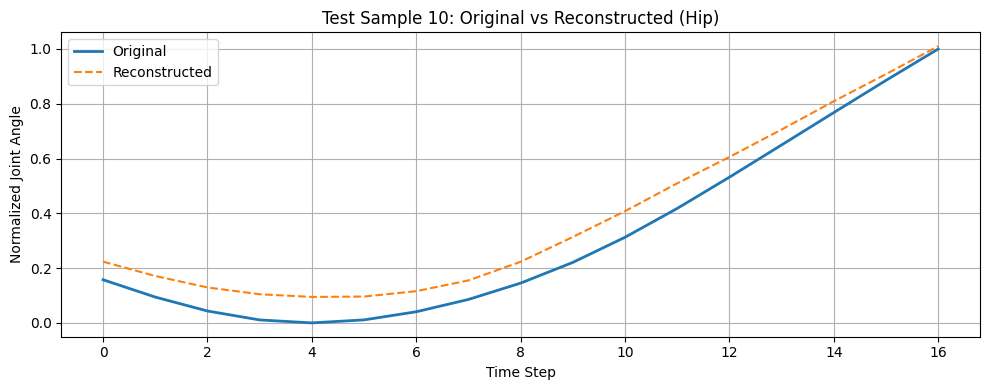

In [226]:
#Testing

test_loss, test_accuracy = final_model_hip.evaluate(X_test_hip, y_test_hip, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Reconstruction Accuracy: {test_accuracy:.4f}")

y_pred_hip = final_model_hip.predict(X_test_hip)
reconstruction_error = np.mean(np.abs(y_pred_hip - y_test_hip), axis=(1,2))  # Mean Absolute Error per sample

# Plot error distribution
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error, bins=50, color='skyblue', edgecolor='black')
plt.title("Reconstruction Error Distribution on Test Set (Hip)")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\testing\hip\hip_test_reconstruction_error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


num_examples = 10
for i in range(num_examples):
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_hip[i].squeeze(), label='Original', linewidth=2)
    plt.plot(y_pred_hip[i].squeeze(), label='Reconstructed', linestyle='--')
    plt.title(f"Test Sample {i+1}: Original vs Reconstructed (Hip)")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Joint Angle")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(rf"C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\testing\hip\hip_test_sample_{i+1}_reconstruction.png", dpi=300, bbox_inches='tight')
    plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0188 - reconstruction_accuracy: 0.7054 
Test Loss: 0.0210
Test Reconstruction Accuracy: 0.6955
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


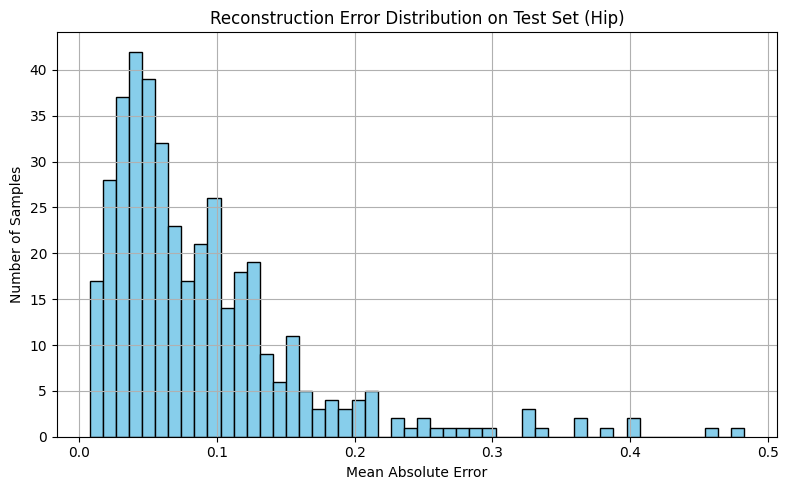

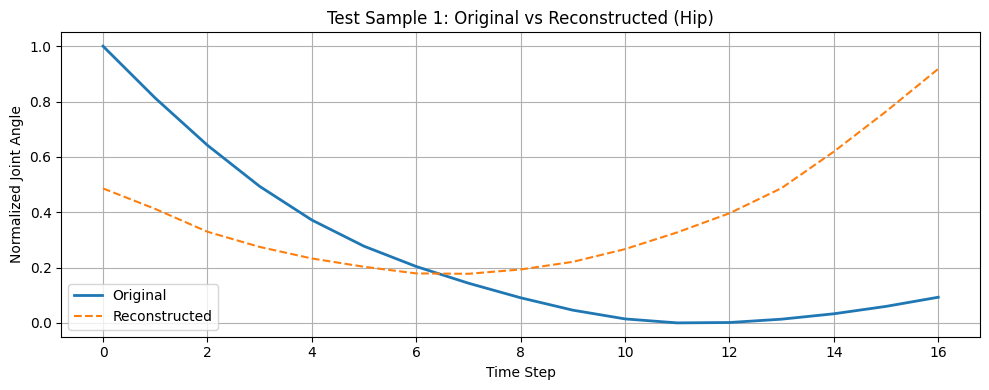

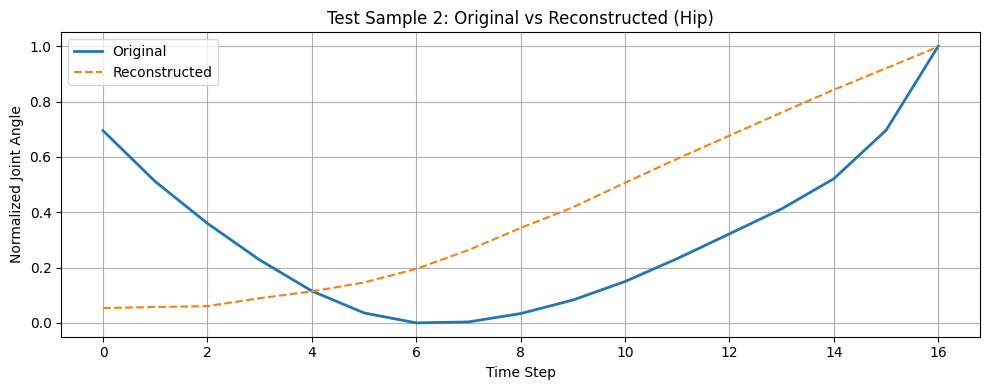

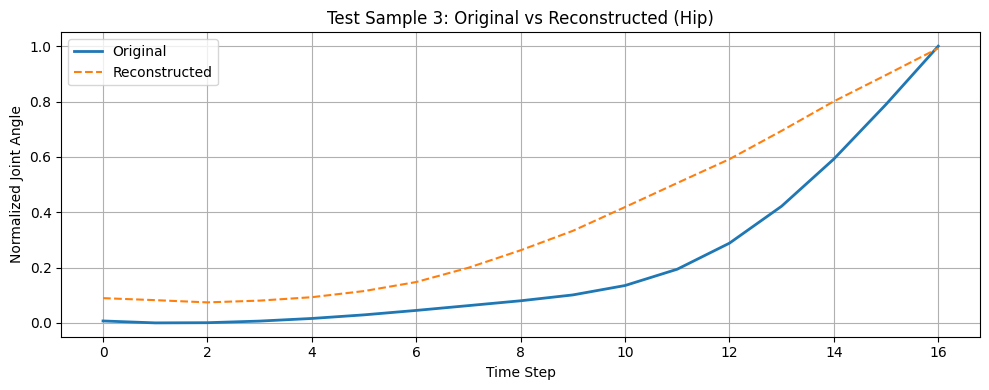

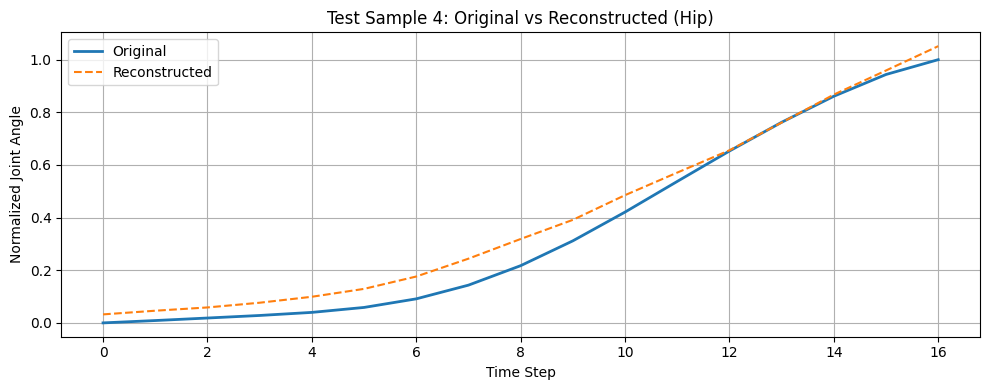

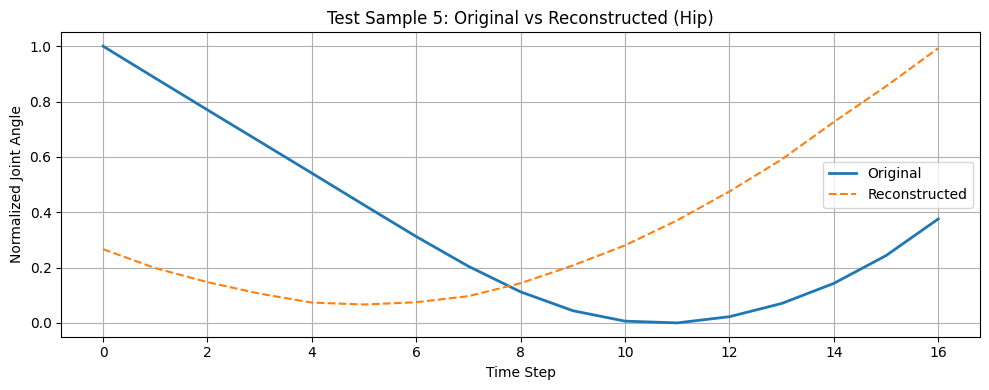

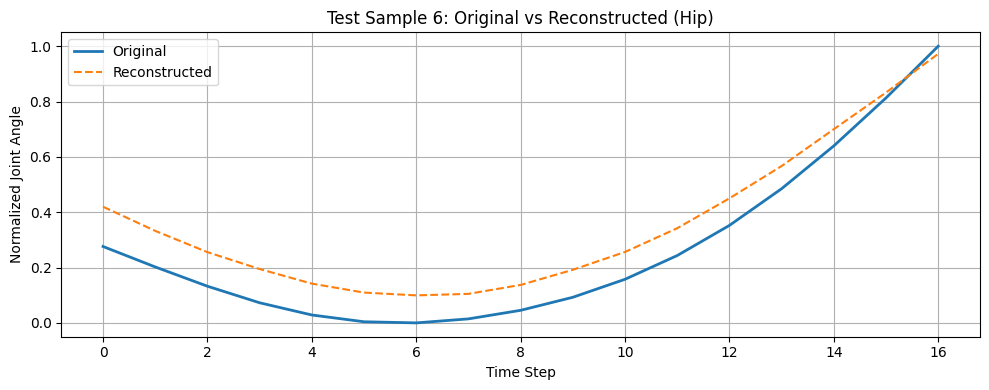

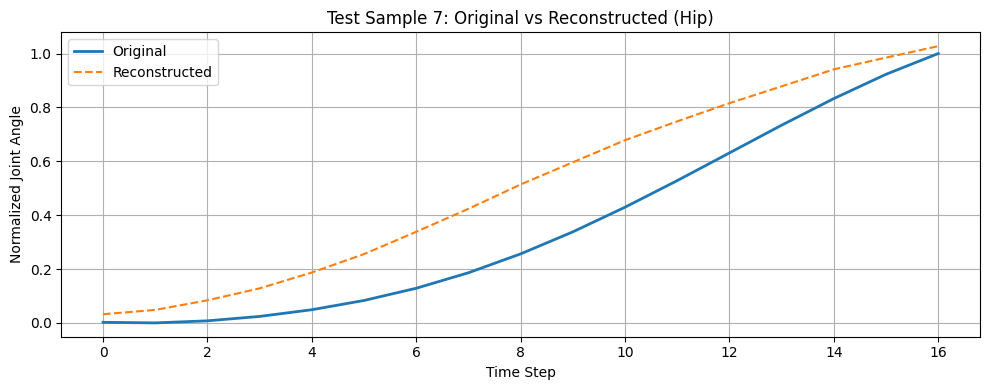

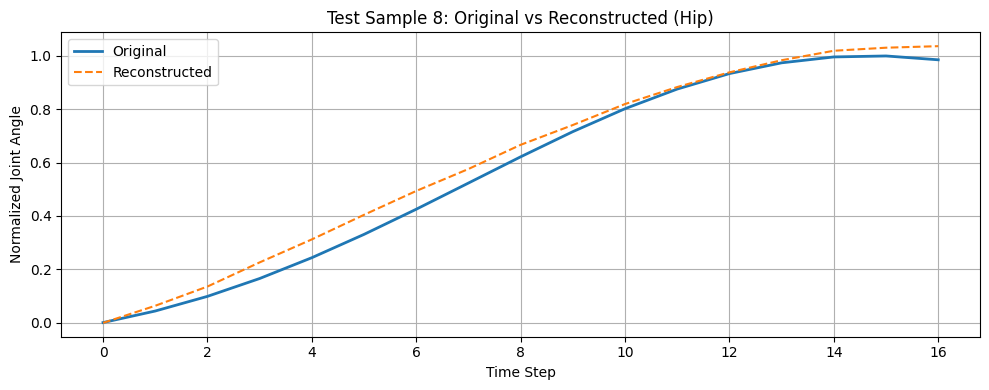

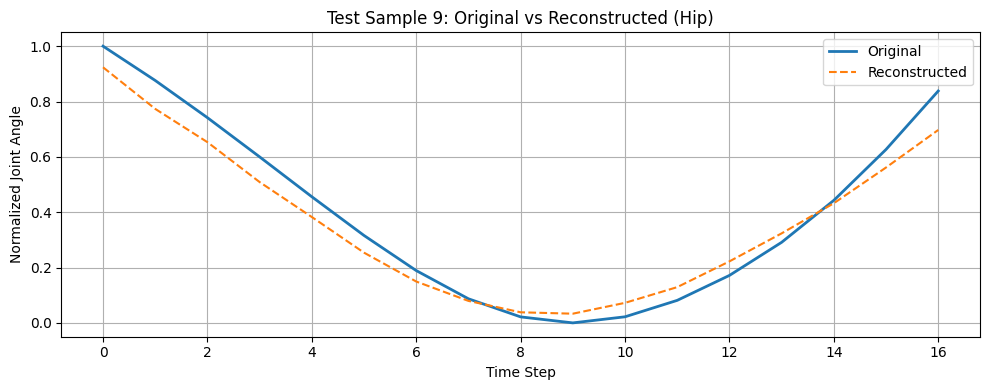

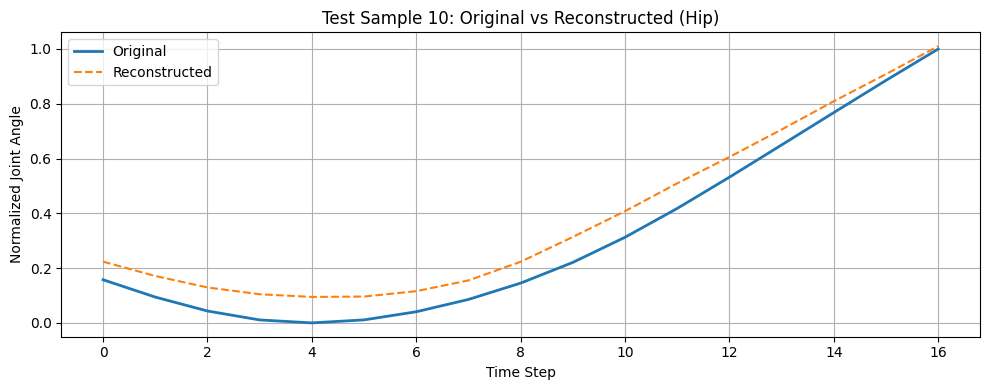

In [227]:
#Testing

test_loss, test_accuracy = final_model_knee.evaluate(X_test_knee, y_test_knee, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Reconstruction Accuracy: {test_accuracy:.4f}")

y_pred_knee = final_model_knee.predict(X_test_knee)
reconstruction_error = np.mean(np.abs(y_pred_knee - y_test_knee), axis=(1,2))  # Mean Absolute Error per sample

# Plot error distribution
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error, bins=50, color='skyblue', edgecolor='black')
plt.title("Reconstruction Error Distribution on Test Set (Hip)")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\testing\knee\knee_test_reconstruction_error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


num_examples = 10
for i in range(num_examples):
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_hip[i].squeeze(), label='Original', linewidth=2)
    plt.plot(y_pred_hip[i].squeeze(), label='Reconstructed', linestyle='--')
    plt.title(f"Test Sample {i+1}: Original vs Reconstructed (Hip)")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Joint Angle")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(rf"C:\Users\Admin\Desktop\CP\Outputs\results\Version 2\testing\knee\knee_test_sample_{i+1}_reconstruction.png", dpi=300, bbox_inches='tight')
    plt.show()


In [232]:
latent_vectors_hip = np.load(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\latent_vectors_hip.npy')
latent_vectors_knee = np.load(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\latent_vectors_knee.npy')
print(latent_vectors_knee.shape)
print(latent_vectors_hip.shape)

# For HIP (use only training set)
window_patient_ids_hip = get_window_patient_ids(
    patient_ids_seq=patient_ids_train_seq,
    full_sequence_length=hip_train.shape[1],
    window_size=window_size,
    step=step
)

# For KNEE (use only training set)
window_patient_ids_knee = get_window_patient_ids(
    patient_ids_seq=patient_ids_train_seq,
    full_sequence_length=knee_train.shape[1],
    window_size=window_size,
    step=step
)

# Combine latent vectors from both models
combined_latent_vectors = np.concatenate((latent_vectors_hip, latent_vectors_knee), axis=0)
# Combine patient IDs from both models  
window_patient_ids = np.concatenate((window_patient_ids_hip, window_patient_ids_knee), axis=0)

# Save combined latent vectors and patient IDs
np.save(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\combined_latent_vectors.npy', combined_latent_vectors)
np.save(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\window_patient_ids.npy', window_patient_ids)

# Load combined latent vectors and patient IDs  
combined_latent_vectors = np.load(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\combined_latent_vectors.npy')
window_patient_ids = np.load(r'C:\Users\Admin\Desktop\CP\Outputs\latent_dim\Version 1\window_patient_ids.npy')

# Check the shape of the combined latent vectors
print("Combined latent vectors shape:", combined_latent_vectors.shape)
# Check the shape of the patient IDs
print("Window patient IDs shape:", window_patient_ids.shape)

# Confirm patient_ids length matches your latent vectors
assert len(window_patient_ids) == combined_latent_vectors.shape[0], "Mismatch in number of samples and patient IDs"

(1800, 80)
(1800, 80)
Combined latent vectors shape: (3600, 80)
Window patient IDs shape: (3600,)


In [ ]:
# Cluster with best k
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(combined_latent_vectors)

# Create DataFrame with patient IDs and cluster labels per window
df_clusters = pd.DataFrame({
    'patient_id': window_patient_ids,
    'cluster': cluster_labels
})

print(df_clusters.head(10))

  patient_id  cluster
0          1        4
1          1        4
2          1        0
3          1        2
4          3        4


In [245]:
df_clusters['patient_id'].unique().__len__()

450

In [252]:
#frequency of patient IDs in each cluster
cluster_counts = df_clusters['cluster'].unique()

In [253]:
cluster_counts

array([4, 0, 2, 1, 3])

In [261]:
print(df_clusters.tail(100))

     patient_id  cluster
3500       CP73        1
3501       CP73        1
3502       CP73        3
3503       CP73        3
3504        CP8        1
...         ...      ...
3595       CP83        3
3596       CP98        1
3597       CP98        3
3598       CP98        3
3599       CP98        3

[100 rows x 2 columns]


In [258]:
#frequency of patient IDs 
cluster_counts = df_clusters['patient_id'].value_counts()
# Save the DataFrame to a CSV file

In [259]:
cluster_counts

patient_id
1        8
CP109    8
CP187    8
CP184    8
CP183    8
        ..
172      8
171      8
170      8
169      8
CP98     8
Name: count, Length: 450, dtype: int64

In [262]:
df_clusters.to_csv(r'C:\Users\Admin\Desktop\CP\Outputs\cluster_output\cluster_labels.csv', index=False)

In [267]:
print("Unique patient IDs in window_patient_ids:", np.unique(window_patient_ids))
print("Number of unique patient IDs:", len(np.unique(window_patient_ids)))

Unique patient IDs in window_patient_ids: ['1' '10' '101' '102' '104' '105' '108' '109' '11' '110' '111' '112' '113'
 '114' '115' '116' '117' '118' '119' '12' '120' '121' '123' '124' '125'
 '126' '127' '128' '129' '13' '130' '132' '133' '134' '135' '136' '137'
 '138' '139' '140' '141' '142' '143' '144' '145' '146' '147' '148' '149'
 '15' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '16'
 '160' '163' '164' '165' '166' '168' '169' '17' '170' '171' '172' '173'
 '174' '175' '176' '177' '178' '179' '18' '180' '181' '182' '183' '184'
 '185' '186' '187' '189' '19' '193' '194' '195' '196' '197' '198' '199'
 '20' '200' '201' '203' '204' '205' '207' '209' '210' '211' '212' '214'
 '216' '219' '220' '221' '222' '223' '224' '225' '226' '227' '229' '23'
 '230' '231' '232' '233' '234' '235' '236' '237' '239' '24' '240' '241'
 '242' '244' '246' '247' '248' '249' '25' '250' '251' '252' '255' '256'
 '257' '258' '259' '26' '260' '262' '263' '264' '267' '268' '269' '27'
 '270' '273' '274' '